# Model comparison

Compare mean average precision (mAP) across `cell_dino`, `cell_profiler`, `dino`, `dynaclr`, and `subcell` models on two evaluation tasks: phenotypic distinctiveness and EBI protein complex consistency.

## Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["svg.fonttype"] = "none"

FIGURES_DIR = Path("../../output/figure_2")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## CSV paths

Combined evaluation CSVs produced by `data_preprocessing/figure_2.py`. Each file is long-format with a `model` column.

**Before public release**, replace this cell with download instructions (or a pointer to the public dataset) and update the constants to match the released layout.

In [2]:
DATA_DIR = Path("../../data_preprocessing/data")

DISTINCTIVENESS_CSV = DATA_DIR / "model_comparison_distinctiveness.csv"
COMPLEX_EBI_CSV     = DATA_DIR / "model_comparison_complex_ebi.csv"

## Load evaluation metrics

Read the two combined CSVs and take the mean `mean_average_precision` per model for each task.

In [3]:
MODELS = ["cell_dino", "dino", "cell_profiler", "dynaclr", "subcell"]

distinctiveness = pd.read_csv(DISTINCTIVENESS_CSV)
complex_ebi     = pd.read_csv(COMPLEX_EBI_CSV)

df = pd.DataFrame({
    "mean_map_distinct":      distinctiveness.groupby("model")["mean_average_precision"].mean(),
    "mean_map_complexes_ebi": complex_ebi.groupby("model")["mean_average_precision"].mean(),
}).reindex(MODELS)
df

,mean_map_distinct,mean_map_complexes_ebi
model,,
cell_dino,0.430385,0.505099
dino,0.349278,0.437293
cell_profiler,0.166758,0.316773
dynaclr,0.199676,0.393047
subcell,0.349443,0.416245


## Mean average precision across metric types

Single panel showing the mAP values across the two metric types for each model. Saves an SVG for the paper figure.

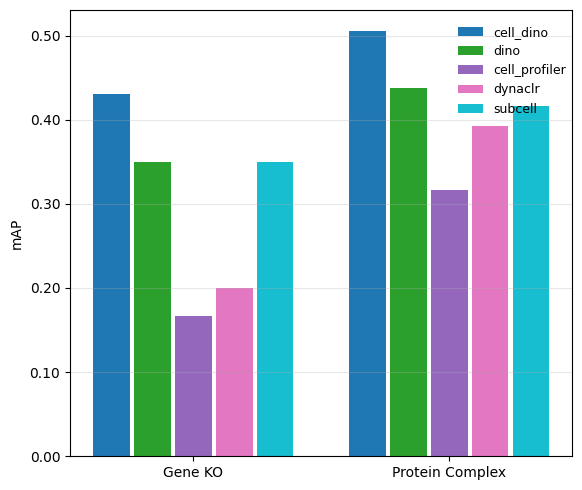

In [4]:
METRICS = ["mean_map_distinct", "mean_map_complexes_ebi"]
METRIC_LABELS = {
    "mean_map_distinct":      "Gene KO",
    "mean_map_complexes_ebi": "Protein Complex",
}

n_models = len(MODELS)
colors = plt.cm.tab10(np.linspace(0, 0.9, n_models))
bar_w = 0.8 / n_models
x = np.arange(len(METRICS))

fig, ax = plt.subplots(figsize=(6, 5))
for i, (model, color) in enumerate(zip(MODELS, colors)):
    offset = (i - (n_models - 1) / 2) * bar_w
    vals = [df.loc[model, m] for m in METRICS]
    ax.bar(x + offset, vals, width=bar_w * 0.9, label=model, color=color)

ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], fontsize=10)
ax.set_ylabel("mAP", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=9, frameon=False, bbox_to_anchor=(0.75, 0.99), loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison_map.svg", bbox_inches="tight")
plt.show()